In [1]:
# pip install kagglehub

In [46]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import LabelEncoder
import openpyxl

https://www.kaggle.com/datasets/vipulshinde/incident-response-log

Attribute Information:

1. number: идентификатор инцидента (24 918 различных значений);
2. incident state: восемь уровней, контролирующих переход процесса управления инцидентами от открытия к закрытию дела;
3. active: логический атрибут, показывающий, активна ли запись или закрыта/отменена;
4. reassignment_count: количество раз, когда в инциденте менялась группа или аналитики поддержки;
5. reopen_count: количество раз, когда решение инцидента было отклонено вызывающим абонентом;
6. sys_mod_count: количество обновлений инцидентов до этого момента;
7. made_sla: логический атрибут, показывающий, превысил ли инцидент целевой SLA (классический случай, когда описание в документации неточное или вводит в заблуждение. Принимаем True как выполнение SLA);
8. caller_id: идентификатор затронутого пользователя;
9. opened_by: идентификатор пользователя, сообщившего об инциденте;
10. opened_at: дата и время открытия пользователя инцидента;
11. sys_created_by: идентификатор пользователя, зарегистрировавшего инцидент;
12. sys_created_at: дата и время создания системы инцидента;
13. sys_updated_by: идентификатор пользователя, обновившего инцидент и сгенерировавшего текущую запись журнала;
14. sys_updated_at: дата и время обновления системы инцидента;
15. contact_type: категориальный атрибут, показывающий, каким образом был сообщен инцидент;
16. location: идентификатор местоположения затронутого места;
17. category: описание затронутой услуги первого уровня;
18. subcategory: описание затронутой услуги второго уровня (относящееся к описанию первого уровня, т. е. к категории);
19. u_symptom: описание восприятия пользователем доступности услуги;
20. cmdb_ci: идентификатор (элемент подтверждения), используемый для сообщения о затронутом элементе (не обязательно);
21. impact: описание воздействия, вызванного инцидентом (значения: 1: Высокое; 2: Среднее; 3: Низкое);
22. urgency: описание срочности, о которой сообщил пользователь для разрешения инцидента (значения: 1: Высокая; 2: Средняя; 3: Низкая);
23. priority: рассчитывается системой на основе «воздействия» и «срочности»;
24. assignment_group: идентификатор группы поддержки, ответственной за инцидент;
25. assigned_to: идентификатор пользователя, ответственного за инцидент;
26. knowledge: логический атрибут, показывающий, использовался ли документ базы знаний для разрешения инцидента;
27. u_priority_confirmation: логический атрибут, показывающий, было ли дважды проверено поле приоритета;
28. notify: категориальный атрибут, показывающий, были ли сгенерированы уведомления об инциденте;
29. problem_id: идентификатор проблемы, связанной с инцидентом;
30. rfc: (запрос на изменение) идентификатор запроса на изменение, связанного с инцидентом;
31. vendor: идентификатор поставщика, ответственного за инцидент;
32. caused_by: идентификатор RFC, ответственного за инцидент;
33. close_code: идентификатор разрешения инцидента;
34. resolved_by: идентификатор пользователя, решившего инцидент;
35. resolved_at: дата и время решения инцидента пользователем (зависимая переменная);
36. closed_at: дата и время закрытия инцидента пользователя (зависимая переменная).

In [3]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("vipulshinde/incident-response-log")

# print("Path to dataset files:", path)

In [4]:
df = pd.read_csv('data/incident_event_log.csv', na_values=['?']) # NaN замаскированы под "?"

C:\Users\Admin\AppData\Local\Temp\ipykernel_17396\2732078540.py:1: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/incident_event_log.csv', na_values=['?']) # NaN замаскированы под "?"


In [5]:
df.head()

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


In [6]:
print(f'строк: {df.shape[0]}, столбцов: {df.shape[1]}')

строк: 119998, столбцов: 36


In [7]:
print(f'Всего номеров {df['number'].count()}')
print(f'Уникальных {df['number'].nunique()}') # уникальных

Всего номеров 119998
Уникальных 20769


In [8]:
# оставляем последние записи по номеру
df = df.sort_values('sys_mod_count').drop_duplicates('number', keep='last') 

In [9]:
print(f'строк: {df.shape[0]}, столбцов: {df.shape[1]}')

строк: 20769, столбцов: 36


In [10]:
# приводим интересующие столбцы к формату даты
for col in ['opened_at', 'resolved_at', 'closed_at']:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y %H:%M', errors='coerce')

In [11]:
df.isna().sum()[df.isna().sum() == 0]

number                     0
incident_state             0
active                     0
reassignment_count         0
reopen_count               0
sys_mod_count              0
made_sla                   0
opened_at                  0
sys_updated_by             0
sys_updated_at             0
contact_type               0
impact                     0
urgency                    0
priority                   0
knowledge                  0
u_priority_confirmation    0
notify                     0
closed_at                  0
dtype: int64

In [12]:
# Смотрим NaN
df.isna().sum()[df.isna().sum() > 0].sort_values()

caller_id               3
location                6
category                7
subcategory             8
closed_code            81
resolved_by            89
opened_by             714
assigned_to           716
resolved_at          1418
assignment_group     2157
u_symptom            4931
sys_created_at       9079
sys_created_by       9079
problem_id          20445
rfc                 20612
cmdb_ci             20717
vendor              20762
caused_by           20767
dtype: int64

- Есть пропуски в кодах закрытия - целесообразно разобраться в причинах. Возможно, не хватает кодов либо необходимо провести работу с сотрудниками.  
- Есть пропуски в ответственных за инцидент  - проверить бизнес-процесс, брошенных тикетов быть не должно.  
- Такая же проблема с ответственным подразделением.  
- Идентификатор проблемы отсутствует - либо это все клиентские инциденты и нет групповых аварий, либо нарушена связка с системой ГП.  
- Отсутствует работа с Вендором.  

In [13]:
# Убираем лишнее
df_filtered = df[[
    'number',
    'opened_at',
    'resolved_at',
    'made_sla',
    'priority',
    'impact',
    'urgency',
    'contact_type',
    'category',
    'assignment_group',
    'location',
    'reassignment_count',
    'reopen_count',
    'knowledge',
]]
df_filtered.head()

,number,opened_at,resolved_at,made_sla,priority,impact,urgency,contact_type,category,assignment_group,location,reassignment_count,reopen_count,knowledge
119997,INC0029233,2016-05-13 11:49:00,2016-05-17 16:46:00,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 61,Group 73,Location 97,0,0,False
80800,INC0019250,2016-04-14 14:23:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 26,Group 70,Location 108,0,0,False
55877,INC0012888,2016-03-30 09:28:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 42,Group 70,Location 15,0,0,False
80994,INC0019296,2016-04-14 15:24:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 26,Group 70,Location 51,0,0,False
56177,INC0012941,2016-03-30 10:15:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 9,Group 70,Location 204,0,0,False


In [14]:
df_filtered.dtypes

number                        object
opened_at             datetime64[ns]
resolved_at           datetime64[ns]
made_sla                        bool
priority                      object
impact                        object
urgency                       object
contact_type                  object
category                      object
assignment_group              object
location                      object
reassignment_count             int64
reopen_count                   int64
knowledge                       bool
dtype: object

In [15]:
# роли переменных
num_cols = list(df_filtered.select_dtypes(include=['float', 'int']).columns)
cat_cols = list(df_filtered.select_dtypes(exclude=['float', 'int']).columns)
num_cols, cat_cols

(['reassignment_count', 'reopen_count'],
 ['number',
  'opened_at',
  'resolved_at',
  'made_sla',
  'priority',
  'impact',
  'urgency',
  'contact_type',
  'category',
  'assignment_group',
  'location',
  'knowledge'])

### Обзор количественных переменных

In [16]:
df_num_features = df_filtered[num_cols]
df_num_features.sample(5)

,reassignment_count,reopen_count
117063,0,0
60858,0,0
58242,0,0
49564,0,0
65047,0,0


In [17]:
# Поиск выбросов с помощью IQR

Q1 = df_num_features.quantile(0.25)
Q3 = df_num_features.quantile(0.75)
IQR = Q3 - Q1

# Создаём DataFrame с флагами выбросов (True/False)
outlier_flags = ((df_num_features < (Q1 - 1.5 * IQR)) |
                       (df_num_features > (Q3 + 1.5 * IQR)))

# Пример: вывести % выбросов по колонкам
outlier_percent = outlier_flags.mean().sort_values(ascending=False)
print("Процент выбросов по признакам:")
outlier_percent

Процент выбросов по признакам:


reassignment_count    0.121383
reopen_count          0.011267
dtype: float64

In [18]:
df_num_features.describe().T

,count,mean,std,min,25%,50%,75%,max
reassignment_count,20769.0,0.988011,1.618996,0.0,0.0,0.0,1.0,27.0
reopen_count,20769.0,0.013289,0.145941,0.0,0.0,0.0,0.0,8.0


- В среднем, 1 передача тикета - стандартный процесс передачи тикета с 1-ой линии на 2-ую, но есть выбросы (в дальнейшем, прицельный анализ данных тикетов).  
- Количество повторно открытых - низкое.   

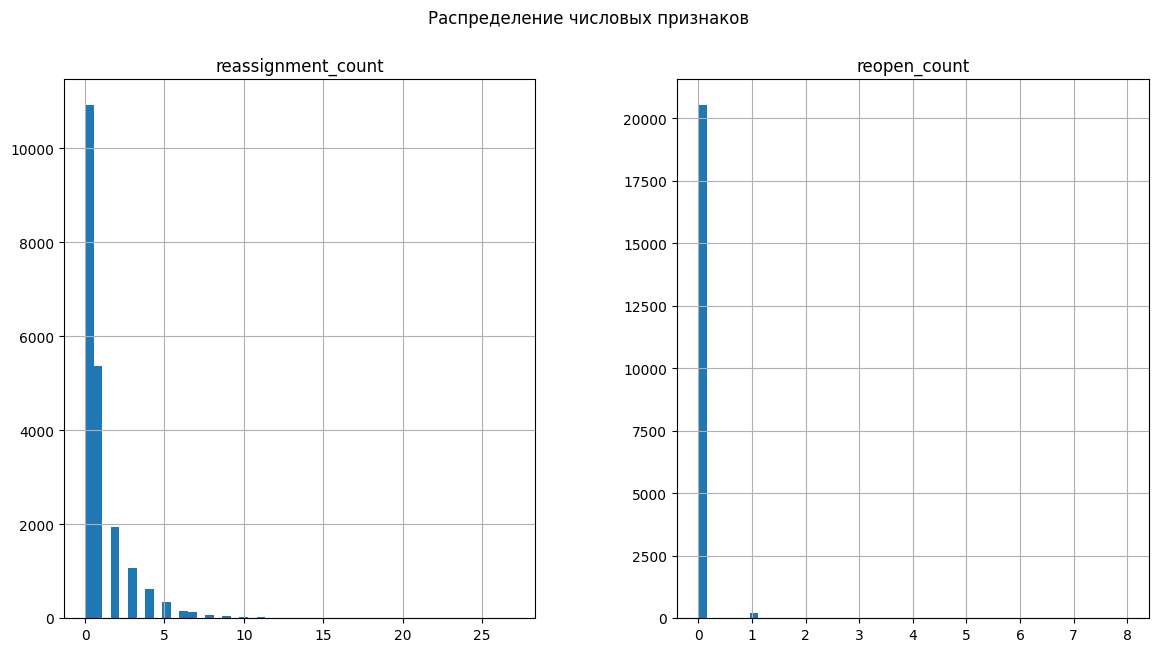

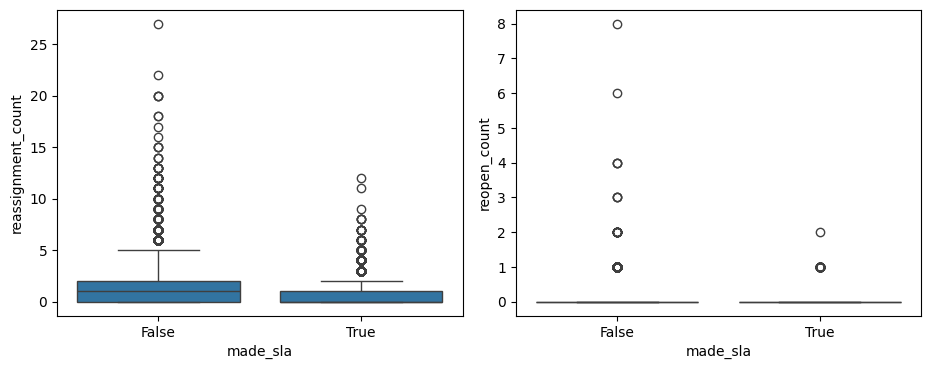

In [19]:
# Гистограммы числовых признаков

df_num_features[num_cols].hist(bins=50, figsize=(14, 7))
plt.suptitle('Распределение числовых признаков')
plt.show()

# Боксплоты числовых признаков по целевой переменной
plt.figure(figsize=(14, 7))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_filtered, x='made_sla', y=col)
plt.tight_layout()
plt.show()

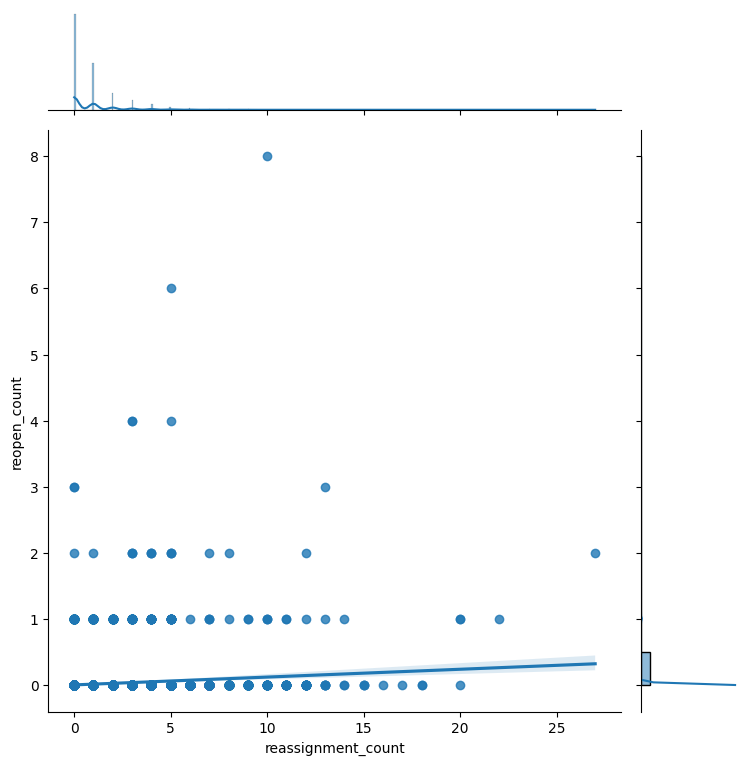

In [20]:
# анализ взаимодействия фичей друг от друга
grid = sns.jointplot(x='reassignment_count', y='reopen_count', data=df_num_features, kind='reg')
grid.figure.set_figwidth(8)
grid.figure.set_figheight(8)

plt.show()

Зависимость взаимодействия фичей не прослеживается.

### Обзор категориальных переменных

In [21]:
df_filtered[cat_cols].columns

Index(['number', 'opened_at', 'resolved_at', 'made_sla', 'priority', 'impact',
       'urgency', 'contact_type', 'category', 'assignment_group', 'location',
       'knowledge'],
      dtype='object')

In [22]:
df_obj_features = df_filtered[cat_cols]
df_obj_features.head()

,number,opened_at,resolved_at,made_sla,priority,impact,urgency,contact_type,category,assignment_group,location,knowledge
119997,INC0029233,2016-05-13 11:49:00,2016-05-17 16:46:00,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 61,Group 73,Location 97,False
80800,INC0019250,2016-04-14 14:23:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 26,Group 70,Location 108,False
55877,INC0012888,2016-03-30 09:28:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 42,Group 70,Location 15,False
80994,INC0019296,2016-04-14 15:24:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 26,Group 70,Location 51,False
56177,INC0012941,2016-03-30 10:15:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 9,Group 70,Location 204,False


In [23]:
df_obj_features['priority'].value_counts()

priority
3 - Moderate    19554
4 - Low           658
2 - High          337
1 - Critical      220
Name: count, dtype: int64

Львиную долю составляют тикеты средней сложности - стандартное рабочее распределение, сетевая инфраструктура в хорошей форме.  

In [24]:
df_obj_features['category'].value_counts(normalize=True).head(10)

category
Category 26    0.135970
Category 42    0.135536
Category 53    0.112947
Category 46    0.095993
Category 32    0.061458
Category 9     0.045275
Category 37    0.045082
Category 23    0.042337
Category 20    0.041855
Category 57    0.035209
Name: proportion, dtype: float64

Целесообразна проверка применения базы знаний и наличие данных по топ-10 категорий услуг.

In [25]:
df_obj_features['location'].value_counts(normalize=True).head()

location
Location 204    0.225642
Location 161    0.153831
Location 143    0.131147
Location 108    0.084622
Location 93     0.079661
Name: proportion, dtype: float64

In [26]:
df_obj_features['location'].isna().sum()

6

Необходимо запланировать проведение встреч с директорами филиалов из топ-3 для разработки совместных мероприятий. На топ-3 приходится половина всех тикетов.

In [27]:
df_obj_features.describe(include='bool').T

,count,unique,top,freq
made_sla,20769,2,True,12595
knowledge,20769,2,False,17232


In [28]:
df_obj_features['knowledge'].value_counts(normalize=True)

knowledge
False    0.829698
True     0.170302
Name: proportion, dtype: float64

Использование базы знаний только в 17% случаев. Целесообразно проверить наполнение БЗ и использование сотрудниками.

In [29]:
list(filter(lambda x: isinstance(x, object), cat_cols))

['number',
 'opened_at',
 'resolved_at',
 'made_sla',
 'priority',
 'impact',
 'urgency',
 'contact_type',
 'category',
 'assignment_group',
 'location',
 'knowledge']

In [30]:
df_obj_features.describe(include='object').T

,count,unique,top,freq
number,20769,20769,INC0029233,1
priority,20769,4,3 - Moderate,19554
impact,20769,3,2 - Medium,19789
urgency,20769,3,2 - Medium,19737
contact_type,20769,2,Phone,20733
category,20762,37,Category 26,2823
assignment_group,18612,64,Group 70,7369
location,20763,202,Location 204,4685


In [31]:
value_priority = df_obj_features.groupby('priority')['made_sla'].median()
value_priority

priority
1 - Critical    0.0
2 - High        0.0
3 - Moderate    1.0
4 - Low         1.0
Name: made_sla, dtype: float64

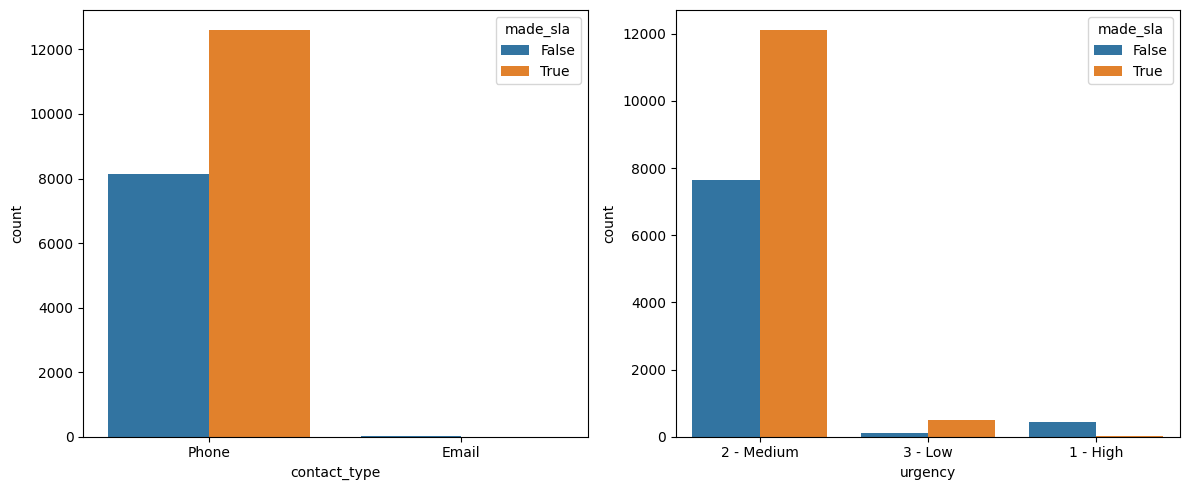

In [32]:
# Столбчатые диаграммы для категориальных признаков
plt.figure(figsize=(12, 5))
for i, col in enumerate(['contact_type', 'urgency'], 1):
    plt.subplot(1, 2, i)
    sns.countplot(data=df_obj_features, x=col, hue='made_sla')
plt.tight_layout()
plt.show()

Заявки в большинстве передаются по телефону как умеренно срочные. (Похоже на клиентов b2c или малого бизнеса)

### Распределение целевой переменной

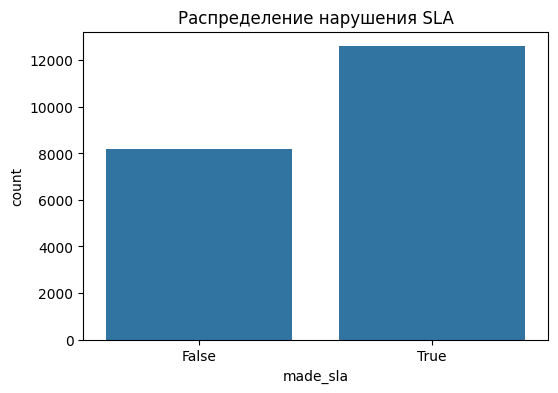


Распределение нарушения SLA:
made_sla
True     0.606433
False    0.393567
Name: proportion, dtype: float64


In [33]:
# Распределение целевой переменной
plt.figure(figsize=(6, 4))
sns.countplot(data=df_filtered, x='made_sla')
plt.title('Распределение нарушения SLA')
plt.show()

print("\nРаспределение нарушения SLA:")
print(df_filtered['made_sla'].value_counts(normalize=True))

Исполнение SLA: 60%  - это очень низкий показатель. У компании явные проблемы с уровнем обслуживания абонентов. 

### Корреляционный анализ

In [34]:
# Проверяем на идентичность написания значений целевого признака
print("Уникальные значения made_sla:", df_filtered['made_sla'].unique())

Уникальные значения made_sla: [ True False]


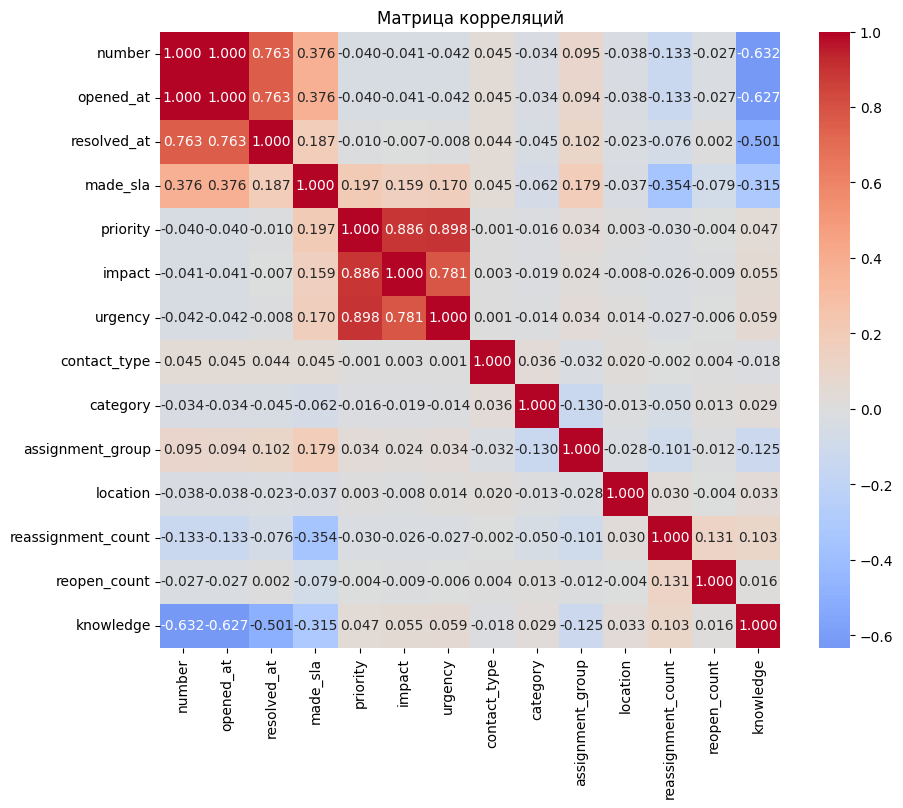

In [35]:
# Кодируем категориальные признаки для корреляционного анализа

# Копируем данные
df_encoded = df_filtered.copy()

# Явно кодируем made_sla: True=1, False=0
# df_encoded['made_sla'] = df_encoded['made_sla'].map({'True': 1, 'False': 0})

le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Матрица корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".3f", cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.show()

Как и предполагалось:  
- Стойкая положительная корреляция целевой переменной с датами открытия и решения, что очевидно.  
- Также положительная корреляция приоритета, воздействия и срочности с исполнением SLA.  

Что менее очевидно, но гипотезы подтвердились:  
- Есть небольшая положительная корреляция между группой поддержки и исполнением SLA.
- Есть отрицательная корреляция между использованием базы знаний и целевой переменной (скорей всего связано с тем, что БЗ пользуются новые сотрудники). 

### Агрегация для DataLens

In [36]:
df_data = df_filtered.copy()

In [37]:
df_data.columns

Index(['number', 'opened_at', 'resolved_at', 'made_sla', 'priority', 'impact',
       'urgency', 'contact_type', 'category', 'assignment_group', 'location',
       'reassignment_count', 'reopen_count', 'knowledge'],
      dtype='object')

In [38]:
df_data['date'] = df_data['opened_at'].dt.date

In [39]:
df_data.head()

,number,opened_at,resolved_at,made_sla,priority,impact,urgency,contact_type,category,assignment_group,location,reassignment_count,reopen_count,knowledge,date
119997,INC0029233,2016-05-13 11:49:00,2016-05-17 16:46:00,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 61,Group 73,Location 97,0,0,False,2016-05-13
80800,INC0019250,2016-04-14 14:23:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 26,Group 70,Location 108,0,0,False,2016-04-14
55877,INC0012888,2016-03-30 09:28:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 42,Group 70,Location 15,0,0,False,2016-03-30
80994,INC0019296,2016-04-14 15:24:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 26,Group 70,Location 51,0,0,False,2016-04-14
56177,INC0012941,2016-03-30 10:15:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 9,Group 70,Location 204,0,0,False,2016-03-30


In [40]:
df_data.columns.drop('opened_at')

Index(['number', 'resolved_at', 'made_sla', 'priority', 'impact', 'urgency',
       'contact_type', 'category', 'assignment_group', 'location',
       'reassignment_count', 'reopen_count', 'knowledge', 'date'],
      dtype='object')

In [41]:
df_data['sla_met'] = (df_data['made_sla'] == True).astype(int)

In [42]:
result = df_data.groupby(['date', 'category', 'priority', 'location']).agg(
    incident_count=('number', 'count'),
    sla_percent=('sla_met', lambda x: round(x.mean() * 100, 2))
).reset_index()


result


,date,category,priority,location,incident_count,sla_percent
0,2016-02-29,Category 13,3 - Moderate,Location 93,2,0.0
1,2016-02-29,Category 17,3 - Moderate,Location 51,1,100.0
2,2016-02-29,Category 19,1 - Critical,Location 143,1,0.0
3,2016-02-29,Category 20,3 - Moderate,Location 108,4,50.0
4,2016-02-29,Category 20,3 - Moderate,Location 136,1,100.0
...,...,...,...,...,...,...
9284,2016-05-13,Category 61,3 - Moderate,Location 51,1,100.0
9285,2016-05-13,Category 61,3 - Moderate,Location 97,1,100.0
9286,2016-05-13,Category 9,3 - Moderate,Location 161,3,100.0
9287,2016-05-13,Category 9,3 - Moderate,Location 204,1,100.0


In [47]:
result.to_excel('report_sla.xlsx', index=False)